DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3567 entries, 0 to 3566
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  3567 non-null   datetime64[ns]
 1   Steps      3567 non-null   int64         
 2   PAM Score  3567 non-null   float64       
 3   tabel      3567 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 111.6 KB
None

First few rows:
            Timestamp  Steps  PAM Score  tabel
0 2025-06-04 14:00:00     15     1.4375      1
1 2025-06-04 14:01:00     35     5.5000      2
2 2025-06-04 14:02:00      1     0.4375      0
3 2025-06-04 14:05:00     35     2.7500      1
4 2025-06-04 14:06:00     56     3.9375      2


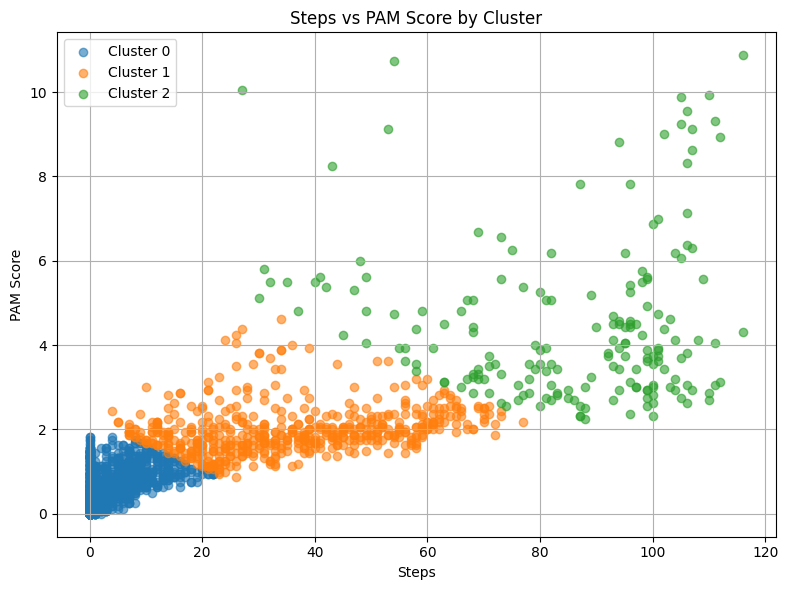

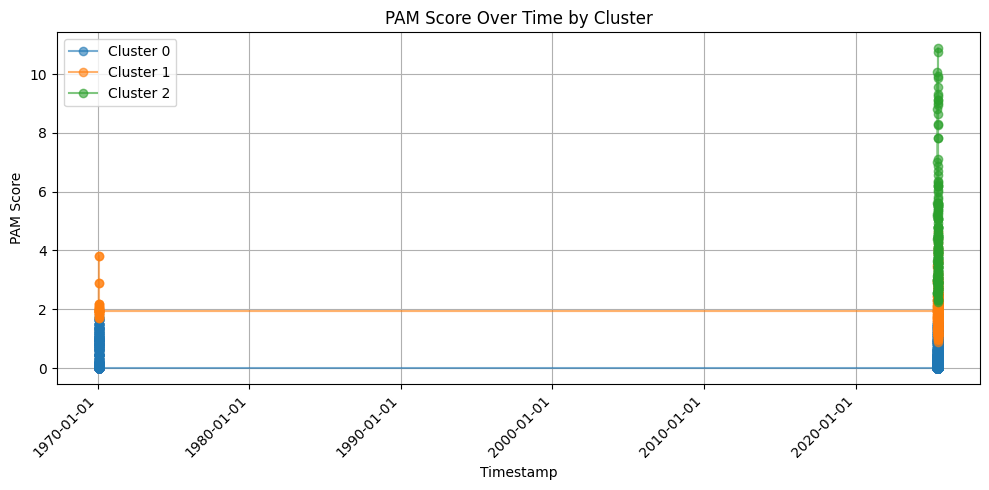

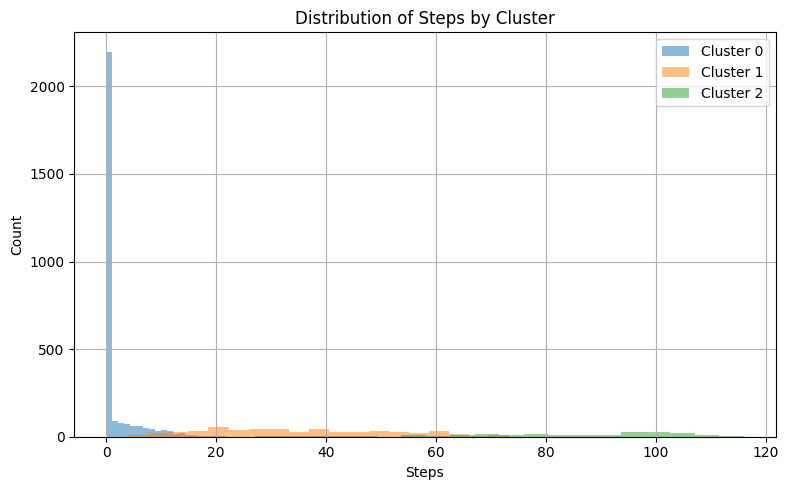

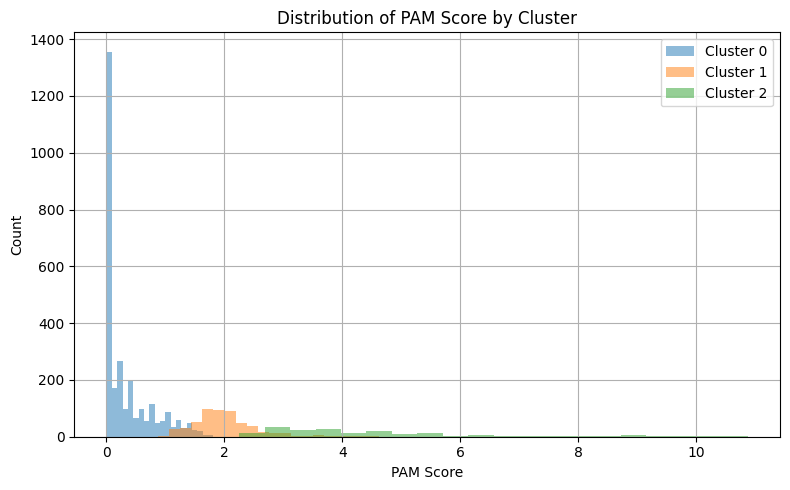

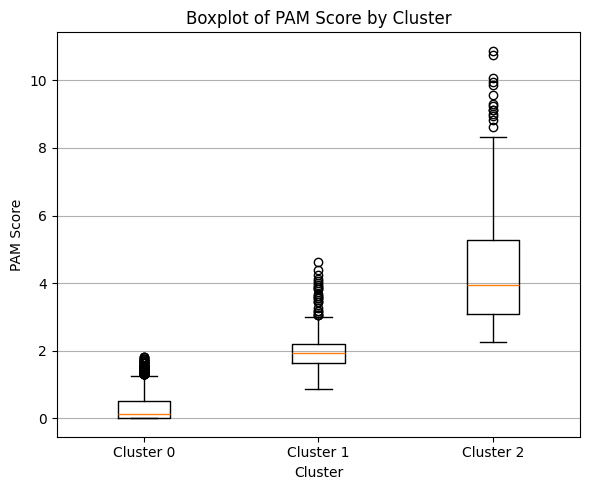

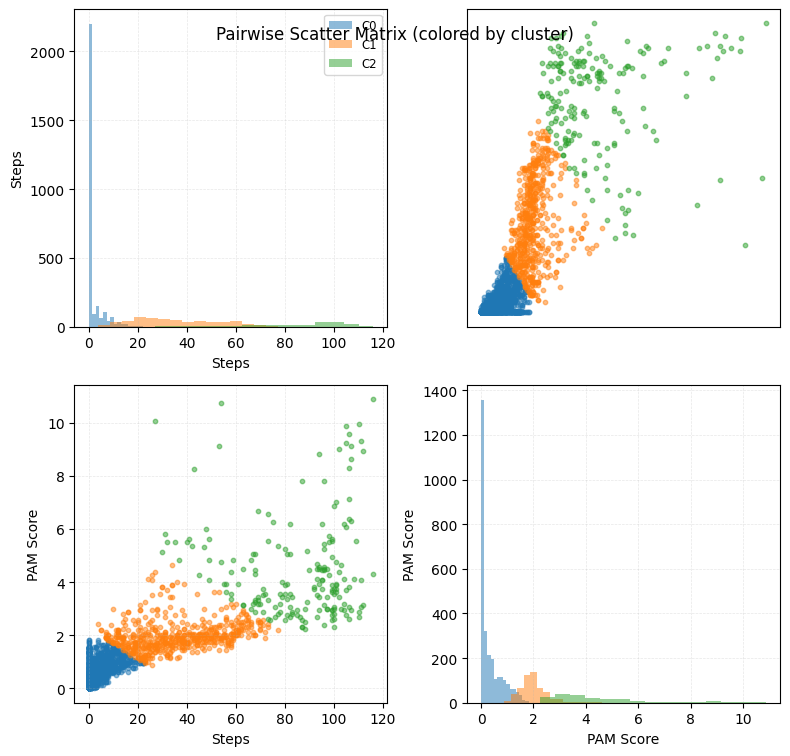

In [17]:
# visualize_clustered_data.py

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================================================================
# 1) LOAD THE LABELED DATA
# =============================================================================

# Adjust this path if your CSV is located elsewhere
CSV_PATH = 'clustered_output_k3.csv'

# Read the CSV into a DataFrame
df = pd.read_csv(CSV_PATH)

# Parse 'Timestamp' into datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Print basic info
print("DataFrame info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())


# =============================================================================
# 2) SCATTER PLOT: STEPS vs PAM SCORE, COLORED BY CLUSTER
# =============================================================================

def plot_steps_vs_pam(df):
    plt.figure(figsize=(8, 6))
    for cluster_label in sorted(df['tabel'].unique()):
        mask = df['tabel'] == cluster_label
        plt.scatter(
            df.loc[mask, 'Steps'],
            df.loc[mask, 'PAM Score'],
            alpha=0.6,
            label=f'Cluster {cluster_label}'
        )
    plt.xlabel('Steps')
    plt.ylabel('PAM Score')
    plt.title('Steps vs PAM Score by Cluster')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 3) TIME SERIES PLOT: PAM SCORE OVER TIME FOR EACH CLUSTER
# =============================================================================

def plot_pam_over_time(df):
    plt.figure(figsize=(10, 5))
    for cluster_label in sorted(df['tabel'].unique()):
        cluster_df = df[df['tabel'] == cluster_label].sort_values('Timestamp')
        plt.plot(
            cluster_df['Timestamp'],
            cluster_df['PAM Score'],
            marker='o',
            linestyle='-',
            alpha=0.6,
            label=f'Cluster {cluster_label}'
        )
    plt.xlabel('Timestamp')
    plt.ylabel('PAM Score')
    plt.title('PAM Score Over Time by Cluster')
    plt.legend()
    plt.grid(True)
    # Format x-axis dates for readability
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# =============================================================================
# 4) HISTOGRAMS: DISTRIBUTION OF EACH NUMERIC FEATURE PER CLUSTER
# =============================================================================

def plot_histograms_per_cluster(df, features):
    """
    For each feature in `features`, create a histogram colored by cluster.
    """
    for feat in features:
        plt.figure(figsize=(8, 5))
        for cluster_label in sorted(df['tabel'].unique()):
            mask = df['tabel'] == cluster_label
            plt.hist(
                df.loc[mask, feat],
                bins=20,
                alpha=0.5,
                label=f'Cluster {cluster_label}'
            )
        plt.xlabel(feat)
        plt.ylabel('Count')
        plt.title(f'Distribution of {feat} by Cluster')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# =============================================================================
# 5) BOXPLOTS: COMPARING A FEATURE ACROSS CLUSTERS
# =============================================================================

def plot_boxplot_feature(df, feature):
    """
    Create a boxplot for `feature` across clusters.
    """
    data_to_plot = [df[df['tabel'] == c][feature].dropna() for c in sorted(df['tabel'].unique())]
    plt.figure(figsize=(6, 5))
    plt.boxplot(
        data_to_plot,
        tick_labels=[f'Cluster {c}' for c in sorted(df['tabel'].unique())]
    )
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.title(f'Boxplot of {feature} by Cluster')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


# =============================================================================
# 6) PAIRWISE SCATTER MATRIX (PAIRPLOT-LIKE) USING MATPLOTLIB
# =============================================================================

def plot_pairwise_scatter(df, features):
    """
    Create a simple pairwise scatter matrix of the given `features`,
    coloring points by cluster.
    """
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))
    for i, feat_x in enumerate(features):
        for j, feat_y in enumerate(features):
            ax = axes[i, j]
            if i == j:
                # Diagonal: show histogram of that feature
                for cluster_label in sorted(df['tabel'].unique()):
                    mask = df['tabel'] == cluster_label
                    ax.hist(
                        df.loc[mask, feat_x],
                        bins=15,
                        alpha=0.5,
                        label=f'C{cluster_label}'
                    )
                if i == 0:
                    ax.legend(loc='upper right', fontsize='small')
                ax.set_ylabel(feat_x)
                ax.set_xlabel(feat_x)
            else:
                # Off-diagonal: scatter plot
                for cluster_label in sorted(df['tabel'].unique()):
                    mask = df['tabel'] == cluster_label
                    ax.scatter(
                        df.loc[mask, feat_y],
                        df.loc[mask, feat_x],
                        alpha=0.5,
                        s=10,
                        label=f'C{cluster_label}' if (i == 0 and j == 1) else ""
                    )
                if i == n - 1:
                    ax.set_xlabel(feat_y)
                else:
                    ax.set_xticks([])
                if j == 0:
                    ax.set_ylabel(feat_x)
                else:
                    ax.set_yticks([])
            # Light grid
            ax.grid(True, linewidth=0.5, linestyle='--', alpha=0.3)
    plt.suptitle('Pairwise Scatter Matrix (colored by cluster)', y=0.92)
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN EXECUTION: CALL ALL PLOTS
# =============================================================================

if __name__ == "__main__":
    # 1) Scatter plot: Steps vs PAM Score
    plot_steps_vs_pam(df)

    # 2) Time series: PAM Score over time
    plot_pam_over_time(df)

    # 3) Histograms for a few key numeric columns
    numeric_columns = [
        col for col in df.columns 
        if df[col].dtype in ['int64', 'float64'] and col not in ['tabel']
    ]
    plot_histograms_per_cluster(df, features=numeric_columns)

    # 4) Boxplot for one feature (e.g., “PAM Score”); change as desired
    plot_boxplot_feature(df, feature='PAM Score')

    # 5) Pairwise scatter matrix for a subset of features (e.g., first 3 numeric columns)
    subset_features = numeric_columns[:3]  # change or extend as needed
    plot_pairwise_scatter(df, features=subset_features)


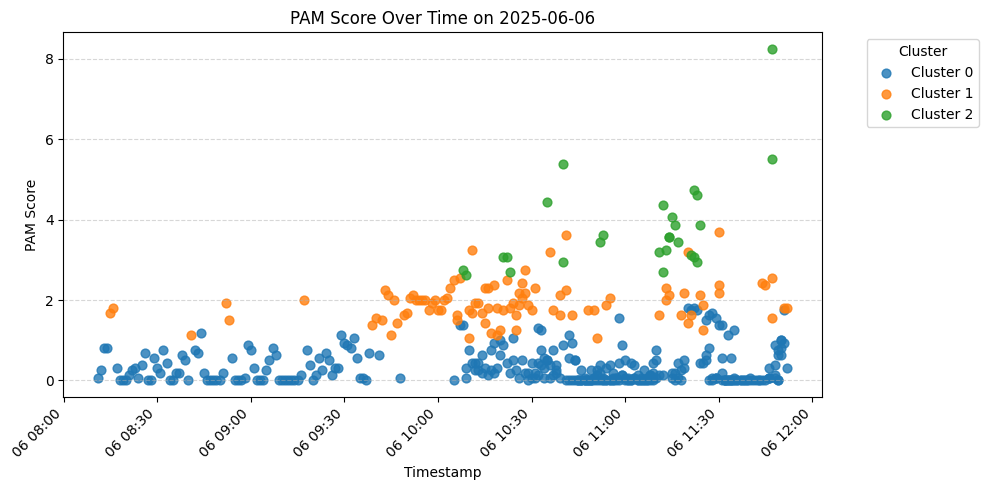

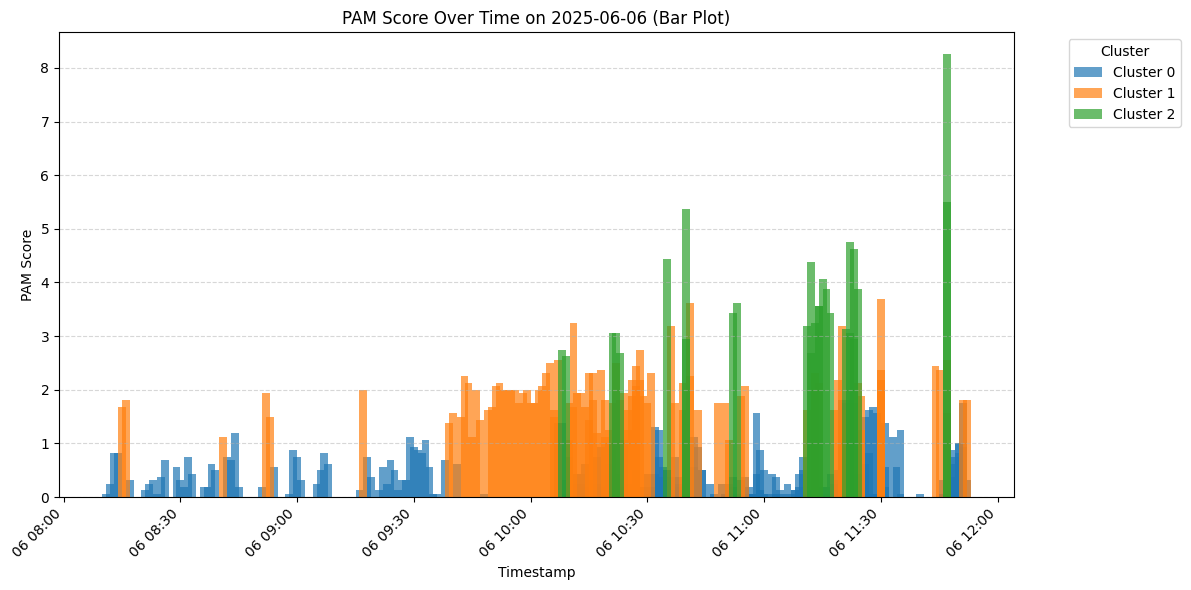

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# --- UPDATE THIS PATH if needed ---
CSV_PATH = 'clustered_output_k3.csv'

# Load the labeled data
df = pd.read_csv(CSV_PATH)

# Parse 'Timestamp' into datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract just the date (year-month-day) from each timestamp
df['DateOnly'] = df['Timestamp'].dt.date

# Find the most recent date in the dataset
last_date = df['DateOnly'].max()

# Filter rows that belong to that last date
last_day_df = df[df['DateOnly'] == last_date]

# Plot PAM Score over time for the last day, colored by cluster
plt.figure(figsize=(10, 5))

for cluster_label in sorted(last_day_df['tabel'].unique()):
    cluster_mask = last_day_df['tabel'] == cluster_label
    plt.scatter(
        last_day_df.loc[cluster_mask, 'Timestamp'],
        last_day_df.loc[cluster_mask, 'PAM Score'],
        s=40,
        alpha=0.8,
        label=f'Cluster {cluster_label}'
    )

plt.xlabel('Timestamp')
plt.ylabel('PAM Score')
plt.title(f'PAM Score Over Time on {last_date}')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Format x-axis dates for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# =============================================================================
# BAR PLOT OF PAM SCORE ON THE LAST DAY, COLORED BY CLUSTER
# =============================================================================

plt.figure(figsize=(12, 6))

# Choose a small width for each bar (e.g., 2 minutes)
bar_width = pd.Timedelta(minutes=2)

for cluster_label in sorted(last_day_df['tabel'].unique()):
    mask = last_day_df['tabel'] == cluster_label
    timestamps = last_day_df.loc[mask, 'Timestamp']
    pam_scores = last_day_df.loc[mask, 'PAM Score']
    
    plt.bar(
        timestamps,
        pam_scores,
        width=bar_width,
        alpha=0.7,
        label=f'Cluster {cluster_label}'
    )

plt.xlabel('Timestamp')
plt.ylabel('PAM Score')
plt.title(f'PAM Score Over Time on {last_date} (Bar Plot)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Format x-axis dates for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


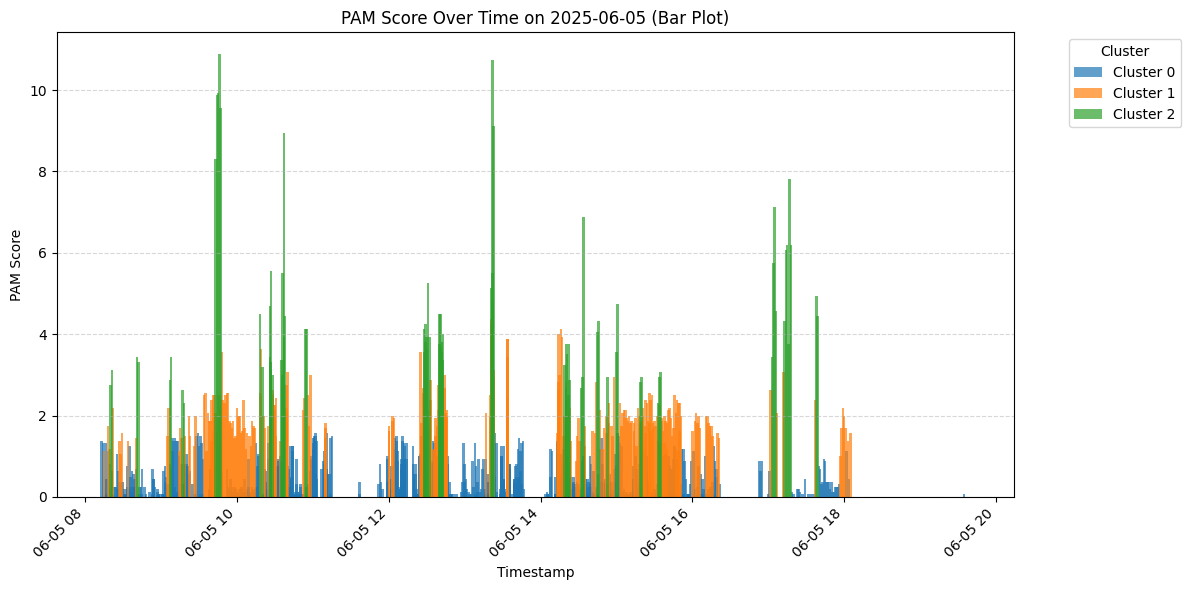

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# --- UPDATE THIS PATH if needed ---
CSV_PATH = 'clustered_output_k3.csv'

# Load the labeled data
df = pd.read_csv(CSV_PATH)

# Parse 'Timestamp' into datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract just the date (year-month-day) from each timestamp
df['DateOnly'] = df['Timestamp'].dt.date

# Find the most recent date in the dataset
last_date = df['DateOnly'].max()

# Compute "yesterday" relative to the most recent date
yesterday_date = last_date - timedelta(days=1)

# Filter rows that belong to yesterday
yesterday_df = df[df['DateOnly'] == yesterday_date]

if yesterday_df.empty:
    print(f"No data found for {yesterday_date}.")
else:
    # =============================================================================
    # BAR PLOT OF PAM SCORE ON YESTERDAY, COLORED BY CLUSTER
    # =============================================================================
    plt.figure(figsize=(12, 6))

    # Choose a small width for each bar (e.g., 2 minutes)
    bar_width = pd.Timedelta(minutes=2)

    for cluster_label in sorted(yesterday_df['tabel'].unique()):
        mask = yesterday_df['tabel'] == cluster_label
        timestamps = yesterday_df.loc[mask, 'Timestamp']
        pam_scores = yesterday_df.loc[mask, 'PAM Score']

        plt.bar(
            timestamps,
            pam_scores,
            width=bar_width,
            alpha=0.7,
            label=f'Cluster {cluster_label}'
        )

    plt.xlabel('Timestamp')
    plt.ylabel('PAM Score')
    plt.title(f'PAM Score Over Time on {yesterday_date} (Bar Plot)')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Format x-axis dates for readability
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


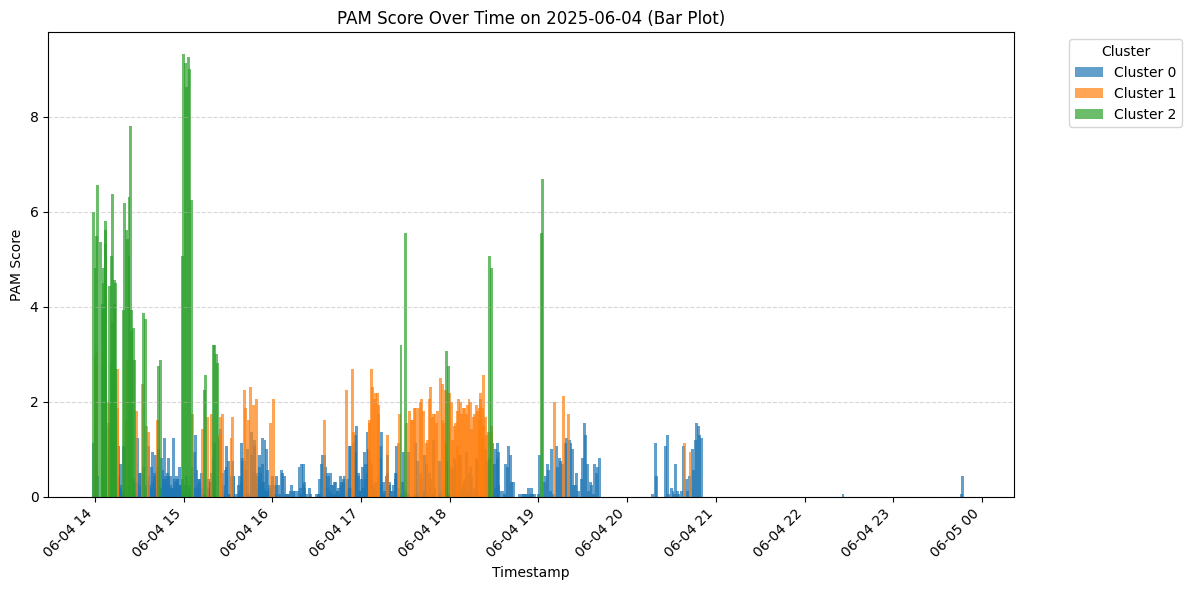

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# --- UPDATE THIS PATH if needed ---
CSV_PATH = 'clustered_output_k3.csv'

# Load the labeled data
df = pd.read_csv(CSV_PATH)

# Parse 'Timestamp' into datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract just the date (year-month-day) from each timestamp
df['DateOnly'] = df['Timestamp'].dt.date

# Find the most recent date in the dataset
last_date = df['DateOnly'].max()

# Compute "day before yesterday" relative to the most recent date
day_before_yesterday = last_date - timedelta(days=2)

# Filter rows that belong to the day before yesterday
day_before_df = df[df['DateOnly'] == day_before_yesterday]

if day_before_df.empty:
    print(f"No data found for {day_before_yesterday}.")
else:
    # =============================================================================
    # BAR PLOT OF PAM SCORE ON DAY BEFORE YESTERDAY, COLORED BY CLUSTER
    # =============================================================================
    plt.figure(figsize=(12, 6))

    # Choose a small width for each bar (e.g., 2 minutes)
    bar_width = pd.Timedelta(minutes=2)

    for cluster_label in sorted(day_before_df['tabel'].unique()):
        mask = day_before_df['tabel'] == cluster_label
        timestamps = day_before_df.loc[mask, 'Timestamp']
        pam_scores = day_before_df.loc[mask, 'PAM Score']

        plt.bar(
            timestamps,
            pam_scores,
            width=bar_width,
            alpha=0.7,
            label=f'Cluster {cluster_label}'
        )

    plt.xlabel('Timestamp')
    plt.ylabel('PAM Score')
    plt.title(f'PAM Score Over Time on {day_before_yesterday} (Bar Plot)')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Format x-axis dates for readability
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
